### Import needed packages and scripts

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from datetime import datetime
import pickle, json, sys, os, glob
import pandas as pd

sys.path.insert(0, os.getcwd() + "/../scripts/")
import auxiliar as aux
import plotting

### Paths to data and results

In [2]:
# Root path of this script
root = os.getcwd() + "/"
# Objects directory
root_data = root + "../data/"
root_tmp = root + "tmp/"

# Filename of the total dictionary
fname_dcheck_srunwise = root_data + "datachecks/dict_datachecks_srunwise.pkl"
# Filename of reduced WS table + date array
fname_ws_reduced = root_data + "ws/reduced_ws_plus_dates.h5"

# Sources ----------------------
# Directory of all the night-wise datachecks
root_dchecks = "/fefs/aswg/workspace/abelardo.moralejo/data/datachecks/night_wise/DL1_datacheck_"
# Weather station file
file_ws_db = root_data + "ws/WS2003-23.h5"

# Some relevant dates
covid_lockdown   = [datetime.fromisoformat("2020-03-14"), datetime.fromisoformat("2020-06-21")]
volcano_eruption = [datetime.fromisoformat("2021-09-19"), datetime.fromisoformat("2021-12-13")]

### Opening the dictionary containing all the data

In [3]:
# Read the file:
with open(fname_dcheck_srunwise, "rb") as f:
        dict_dcheck_srunwise = pickle.load(f)   

### Averaging results in runs

In [4]:
%%time
run_number        = []
number_of_subruns = []
timestamp         = []
telapsed          = []
azimuth    = []
zenith     = []
intensity_at_half_peak_rate = []
pwl_norm                    = []
pwl_delta_norm              = []
pwl_index                   = []
pwl_delta_index             = []
light_yield                 = []
temperature        = []
pressure           = []
humidity           = []
wind_speed         = []
wind_gust          = []
wind_speed_average = []
tng_dust           = []
tng_seeing         = []
rain               = []

for i, run in enumerate(dict_dcheck_srunwise.keys()):

    print(f"Reading and averaging... {i:6}/{len(dict_dcheck_srunwise.keys())} runs") if i % 500 == 0 else None

#     try:
    run_number.append(run)
    number_of_subruns.append(len(dict_dcheck_srunwise[run].keys()))
    timestamp.append(dict_dcheck_srunwise[run][np.sort(list(dict_dcheck_srunwise[run].keys()))[0]]["time"])
    telapsed.append(np.sum(
        [dict_dcheck_srunwise[run][srun]["telapsed"] for srun in dict_dcheck_srunwise[run].keys()]))
    azimuth.append(np.mean(
        [dict_dcheck_srunwise[run][srun]["az"] for srun in dict_dcheck_srunwise[run].keys()]))
    zenith.append(np.mean(
        [dict_dcheck_srunwise[run][srun]["zd"] for srun in dict_dcheck_srunwise[run].keys()]))

    intensity_at_half_peak_rate.append(np.mean([dict_dcheck_srunwise[run][srun][
        "ZD_corrected_intensity_at_half_peak_rate"] for srun in dict_dcheck_srunwise[run].keys()]))
    pwl_norm.append(np.mean([dict_dcheck_srunwise[run][srun][
        "ZD_corrected_cosmics_rate_at_422_pe"] for srun in dict_dcheck_srunwise[run].keys()]))
    pwl_delta_norm.append(np.mean([dict_dcheck_srunwise[run][srun][
        "ZD_corrected_delta_cosmics_rate_at_422_pe"] for srun in dict_dcheck_srunwise[run].keys()]))
    pwl_index.append(np.mean([dict_dcheck_srunwise[run][srun][
        "ZD_corrected_cosmics_spectral_index"] for srun in dict_dcheck_srunwise[run].keys()]))
    pwl_delta_index.append(np.mean([dict_dcheck_srunwise[run][srun][
        "delta_cosmics_spectral_index"] for srun in dict_dcheck_srunwise[run].keys()]))
    light_yield.append(np.mean([dict_dcheck_srunwise[run][srun][
        "light_yield"] for srun in dict_dcheck_srunwise[run].keys()]))

    temperature.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["temperature"] for srun in dict_dcheck_srunwise[run].keys()]))
    pressure.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["pressure"] for srun in dict_dcheck_srunwise[run].keys()]))
    humidity.append(np.mean([dict_dcheck_srunwise[
            run][srun]["weather"]["humidity"] for srun in dict_dcheck_srunwise[run].keys()]))
    wind_speed.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["wind_speed"] for srun in dict_dcheck_srunwise[run].keys()]))
    wind_gust.append(np.mean([dict_dcheck_srunwise[
            run][srun]["weather"]["wind_gust"] for srun in dict_dcheck_srunwise[run].keys()]))
    wind_speed_average.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["wind_speed_average"] for srun in dict_dcheck_srunwise[run].keys()]))
    tng_dust.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["tng_dust"] for srun in dict_dcheck_srunwise[run].keys()]))
    tng_seeing.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["tng_seeing"] for srun in dict_dcheck_srunwise[run].keys()]))
    rain.append(np.mean([dict_dcheck_srunwise[
        run][srun]["weather"]["rain"] for srun in dict_dcheck_srunwise[run].keys()]))
        
# Now convert to numpy arrays
run_number        = np.array(run_number)
number_of_subruns = np.array(number_of_subruns)
timestamp         = np.array(timestamp)
telapsed          = np.array(telapsed)
azimuth = np.array(azimuth)
zenith  = np.array(zenith)
intensity_at_half_peak_rate = np.array(intensity_at_half_peak_rate)
pwl_norm                    = np.array(pwl_norm)
pwl_delta_norm              = np.array(pwl_delta_norm)
pwl_index                   = np.array(pwl_index)
pwl_delta_index             = np.array(pwl_delta_index)
light_yield                 = np.array(light_yield)
temperature        = np.array(temperature)
pressure           = np.array(pressure)
humidity           = np.array(humidity)
wind_speed         = np.array(wind_speed)
wind_gust          = np.array(wind_gust)
wind_speed_average = np.array(wind_speed_average)
tng_dust           = np.array(tng_dust)
tng_seeing         = np.array(tng_seeing)
rain               = np.array(rain)

Reading and averaging...      0/7771 runs
Reading and averaging...    500/7771 runs
Reading and averaging...   1000/7771 runs
Reading and averaging...   1500/7771 runs
Reading and averaging...   2000/7771 runs
Reading and averaging...   2500/7771 runs
Reading and averaging...   3000/7771 runs
Reading and averaging...   3500/7771 runs
Reading and averaging...   4000/7771 runs
Reading and averaging...   4500/7771 runs
Reading and averaging...   5000/7771 runs
Reading and averaging...   5500/7771 runs
Reading and averaging...   6000/7771 runs
Reading and averaging...   6500/7771 runs
Reading and averaging...   7000/7771 runs
Reading and averaging...   7500/7771 runs
CPU times: user 5.95 s, sys: 135 ms, total: 6.08 s
Wall time: 5.91 s


### Extracting the total data of the WS

In [5]:
%%time
# WS reading
with open(fname_ws_reduced, "rb") as f:
    df_ws, dates_ws = pickle.load(f)
maxdate_ws = np.max(dates_ws)

CPU times: user 171 ms, sys: 309 ms, total: 479 ms
Wall time: 1.38 s


### Plotting all
##### Number of subruns and time elapsed

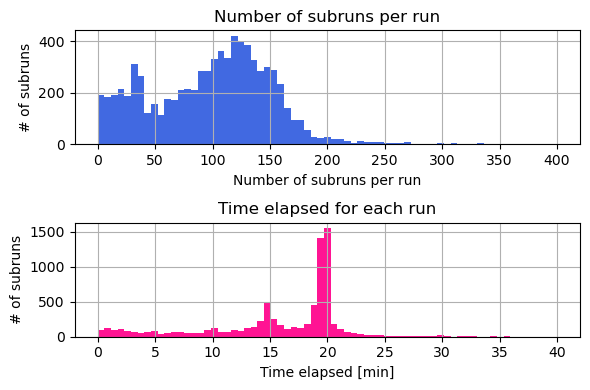

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4))

ax1.hist(number_of_subruns, np.linspace(0, 400, 70), color="royalblue")
ax2.hist(telapsed / 60, np.linspace(0, 40, 70), color="deeppink")

ax1.set_xlabel("Number of subruns per run"); ax1.set_ylabel("# of subruns"); ax1.grid(); ax2.grid()
ax1.set_title("Number of subruns per run"); ax2.set_xlabel("Time elapsed [min]")
ax2.set_ylabel("# of subruns"); ax2.set_title("Time elapsed for each run")

fig.tight_layout()
plt.savefig(f"plots/histogram_nsruns_telapsed.png", bbox_inches="tight", dpi=300)
plt.show()

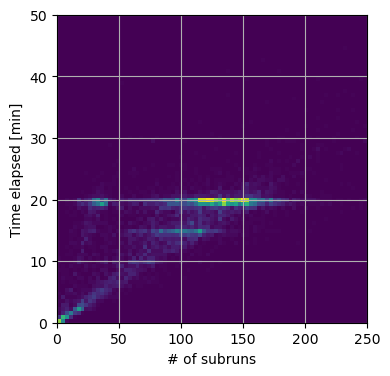

In [7]:
Nbins = 80
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.hist2d(number_of_subruns, telapsed / 60, 
          bins=(np.linspace(0, 250, Nbins), np.linspace(0, 3000/60, Nbins)),)

ax.set_xlim(0, 250); ax.set_ylim(0, 3000/60); ax.grid()
ax.set_ylabel("Time elapsed [min]"); ax.set_xlabel("# of subruns")

plt.savefig(f"plots/histogram_nsruns_telapsed.png", bbox_inches="tight", dpi=300)
plt.show()

##### Time elapsed in run-subrun

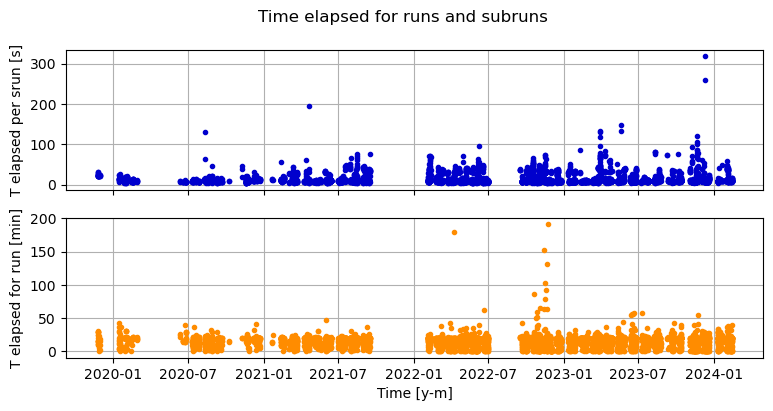

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

ax1.plot(timestamp, telapsed / number_of_subruns, ".", color="mediumblue")
ax2.plot(timestamp, telapsed / 60, ".", color="darkorange")

ax2.set_xlabel("Time [y-m]"); ax1.set_ylabel("T elapsed per srun [s]"); ax2.set_ylabel("T elapsed for run [min]")
ax1.grid(); ax2.grid(); fig.suptitle("Time elapsed for runs and subruns")

plt.savefig(f"plots/evolution_telapsed.png", bbox_inches="tight", dpi=300)
plt.show()

##### Pointings

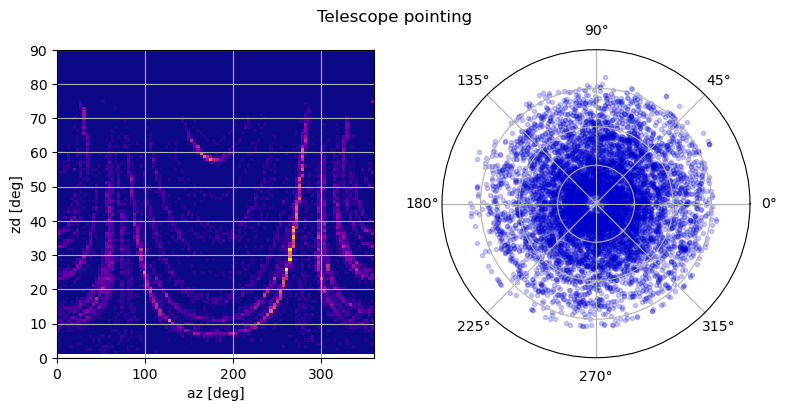

In [22]:
fig = plt.figure(figsize=(9, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection="polar")

ax1.hist2d(azimuth, zenith, 100, cmap="plasma")
ax2.scatter(azimuth, zenith, marker=".", color="mediumblue", alpha=0.2)

for ax in [ax1, ax2]:
    ax.grid(True, zorder=-100)
    ax.set_ylim(0, 90)
ax1.set_xlim(0, 360)
ax2.set_yticks([22.5, 45, 67.5], [])
ax1.set_xlabel("az [deg]")
ax1.set_ylabel("zd [deg]")
fig.suptitle("Telescope pointing")

plt.savefig(f"plots/histogram_telescope_pointings.png", bbox_inches="tight", dpi=300)
plt.show()

##### Peak intensity & Moon phase

In [10]:
date_objects     = np.linspace(min(timestamp).timestamp(), max(timestamp).timestamp(), 2000)
datetime_objects = np.array([datetime.fromtimestamp(timestamp) for timestamp in date_objects])

# Function to calculate moon phase (1 for full moon, 0 for no moon)
def calculate_moon_phase(date):
    # Define the period of the moon's cycle (in seconds)
    lunar_cycle_period = 29.530588 * 24 * 60 * 60  # Approximately 29.53 days
    # Calculate the phase angle in radians
    phase_angle = 2 * np.pi * (date.timestamp() - datetime.strptime("2024-01-25-17:54", "%Y-%m-%d-%H:%M").timestamp()) / lunar_cycle_period
    # Use a sinusoidal function to model the moon phase
    moon_phase = 0.5 + 0.5 * np.sin(phase_angle)
    return moon_phase

# Get moon phases for each datetime object
moon_phases = np.array([calculate_moon_phase(dt) for dt in datetime_objects])

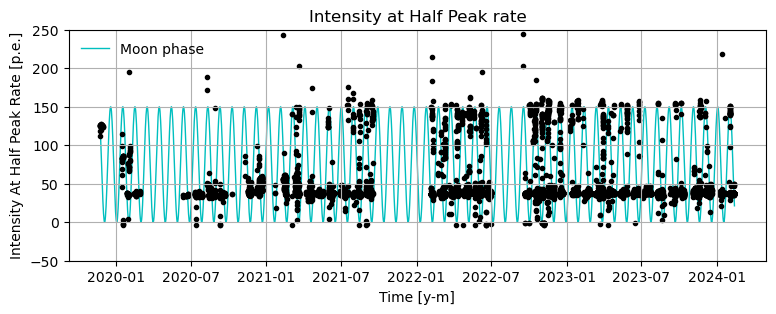

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.scatter(timestamp, intensity_at_half_peak_rate, marker=".", color="k")
ax.plot(datetime_objects, moon_phases*150, zorder=-10, lw=1, color="c", label="Moon phase")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Intensity At Half Peak Rate [p.e.]"); plt.grid()
ax.set_title("Intensity at Half Peak rate"); ax.set_ylim(-50, 250); ax.legend(frameon=False)

plt.savefig(f"plots/evolution_i_half_peak_moon.png", bbox_inches="tight", dpi=300)
plt.show()

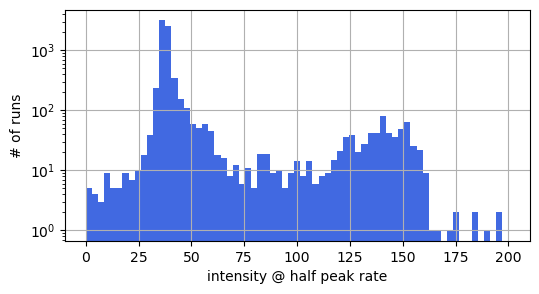

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

ax.hist(intensity_at_half_peak_rate, np.linspace(0, 200, 70), color="royalblue")

ax.set_yscale("log"); ax.set_xlabel("intensity @ half peak rate")
ax.set_ylabel("# of runs"); plt.grid()

plt.savefig(f"plots/histrogram_i_half_peek.png", bbox_inches="tight", dpi=300)
plt.show()

##### Rate @ 422 p.e. parameter of intensity spectrums

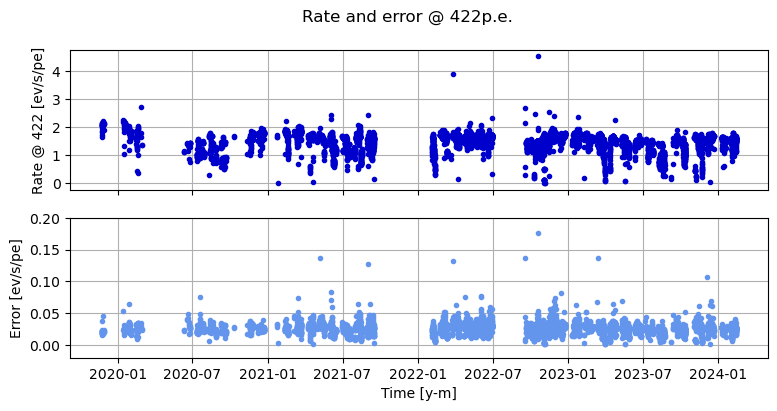

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

ax1.plot(timestamp, pwl_norm, marker=".", ls="", color="mediumblue")
ax2.plot(timestamp, pwl_delta_norm, marker=".", ls="", color="cornflowerblue")

ax2.set_xlabel("Time [y-m]"); ax1.set_ylabel("Rate @ 422 [ev/s/pe]"); ax2.set_ylabel("Error [ev/s/pe]")
ax2.set_ylim(-0.02, 0.2); fig.suptitle("Rate and error @ 422p.e."); ax1.grid(); ax2.grid()

plt.savefig(f"plots/evolution_i_half_peek.png", bbox_inches="tight", dpi=300)
plt.show()

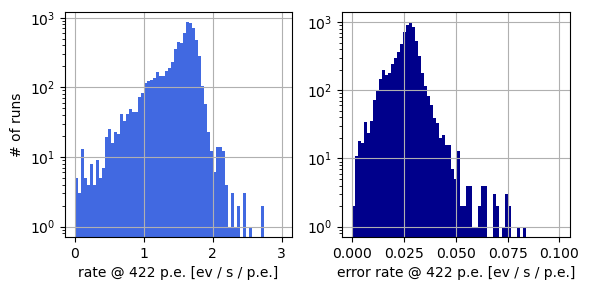

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

ax1.hist(pwl_norm, np.linspace(0, 3, 70), color="royalblue")
ax2.hist(pwl_delta_norm, np.linspace(0, 0.1, 70), color="darkblue")

for ax in [ax1, ax2]:
    ax.set_yscale("log"); ax.grid()
ax1.set_xlabel("rate @ 422 p.e. [ev / s / p.e.]"); ax2.set_xlabel("error rate @ 422 p.e. [ev / s / p.e.]")
ax1.set_ylabel("# of runs"); fig.tight_layout()

plt.savefig(f"plots/histrogram_rate_at_422_pe.png", bbox_inches="tight", dpi=300)
plt.show()

##### Power law index parameter of intensity spectrums

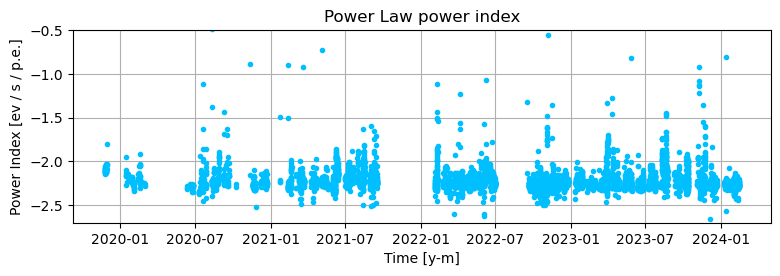

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(9, 2.5))

ax.plot(timestamp, pwl_index, marker=".", ls="", color="deepskyblue")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Power Index [ev / s / p.e.]")
ax.set_ylim(-2.7, -0.5); ax.grid(); ax.set_title("Power Law power index")

plt.savefig(f"plots/evolution_power_law_index.png", bbox_inches="tight", dpi=300)
plt.show()

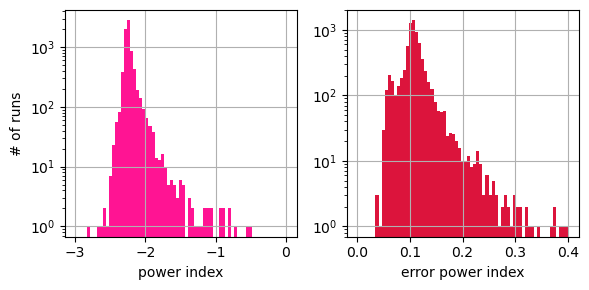

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

ax1.hist(pwl_index, np.linspace(-3, 0, 70), color="deeppink")
ax2.hist(pwl_delta_index, np.linspace(0, 0.4, 70), color="crimson")

for ax in [ax1, ax2]:
    ax.set_yscale("log"); ax.grid()
ax1.set_ylabel("# of runs"); ax1.set_xlabel("power index"); ax2.set_xlabel("error power index")
fig.tight_layout()

plt.savefig(f"plots/histogram_power_law_index.png", bbox_inches="tight", dpi=300)
plt.show()

##### Light Yield of intensity spectrums

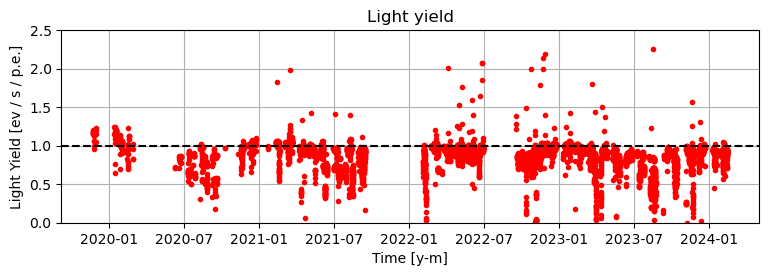

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(9, 2.5))

ax.plot(timestamp, light_yield, marker=".", ls="", color="r")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Light Yield [ev / s / p.e.]"); ax.grid()
ax.set_ylim(0, 2.5); ax.axhline(1, ls="--", color="k"); ax.set_title("Light yield")

plt.savefig(f"plots/evolution_light_yield.png", bbox_inches="tight", dpi=300)
plt.show()

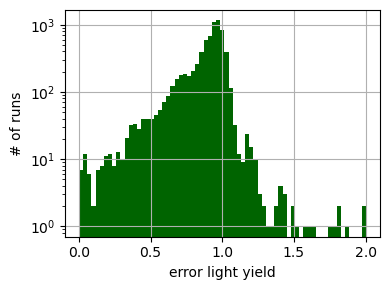

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.hist(light_yield, np.linspace(0, 2, 70), color="darkgreen")

ax.set_ylabel("# of runs"); ax.set_xlabel("light yield"); ax.set_xlabel("error light yield")
ax.set_yscale("log"); ax.grid(); fig.tight_layout()

plt.savefig(f"plots/histogram_light_yield.png", bbox_inches="tight", dpi=300)
plt.show()

##### WS Temperature

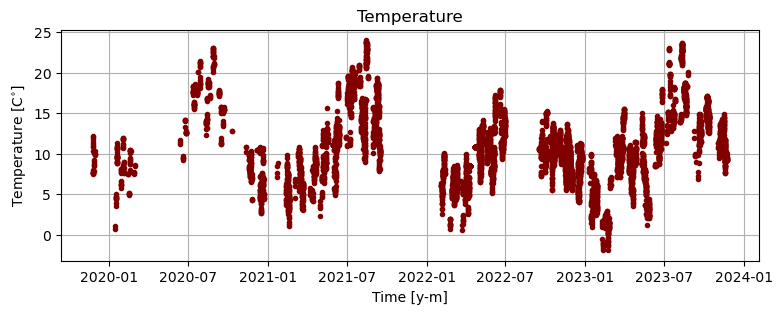

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, temperature, marker=".", ls="", color="maroon")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Temperature [C$^{\circ}$]")
ax.grid(); ax.set_title("Temperature")

plt.savefig(f"plots/evolution_ws_temperature.png", bbox_inches="tight", dpi=300)
plt.show()

##### WS Pressure

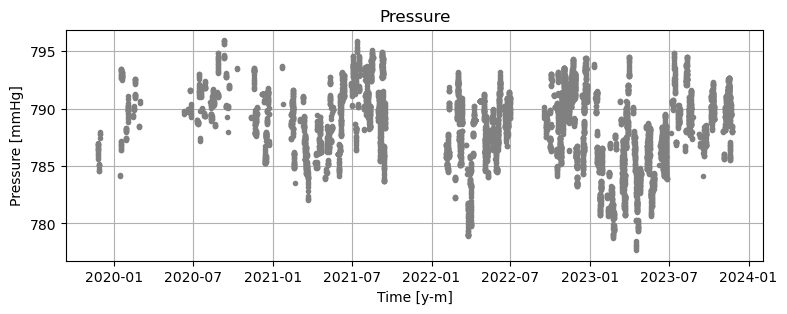

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, pressure, marker=".", ls="", color="gray")

ax.set_xlabel("Time [y-m]")
ax.set_ylabel("Pressure [mmHg]")
ax.grid()
ax.set_title("Pressure")

plt.savefig(f"plots/evolution_ws_pressure.png", bbox_inches="tight", dpi=300)
plt.show()

##### WS Humidity

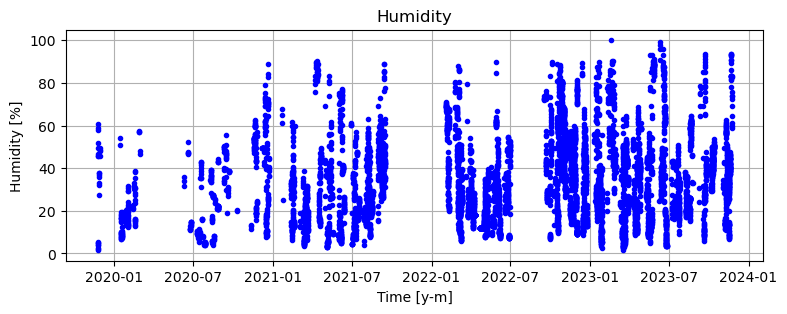

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, humidity, marker=".", ls="", color="b")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Humidity [%]")
ax.grid(); ax.set_title("Humidity")

plt.savefig(f"plots/evolution_ws_humidity.png", bbox_inches="tight", dpi=300)
plt.show()

##### WS Wind

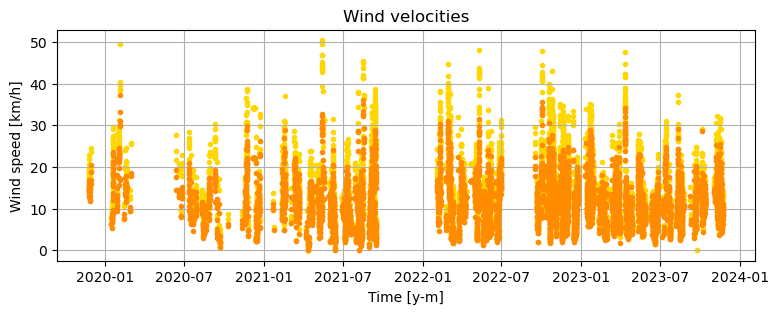

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

# ax.plot(timestamp, wind_speed, marker=".", ls="", color="r", zorder=5)
ax.plot(timestamp, wind_gust, marker=".", ls="", color="gold", zorder=0, label="Wind gust")
ax.plot(timestamp, wind_speed_average, marker=".", ls="", color="darkorange", zorder=10, label="A")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Wind speed [km/h]")
ax.grid(); ax.set_title("Wind velocities")

plt.savefig(f"plots/evolution_ws_wind.png", bbox_inches="tight", dpi=300)
plt.show()

##### Rain periods

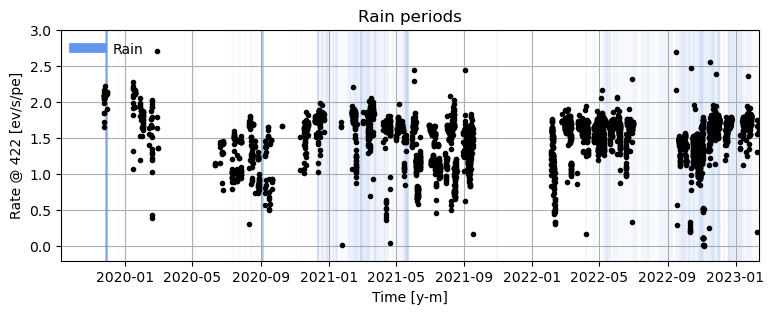

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, pwl_norm, marker=".", ls="", color="k", zorder=10)

rain_total = np.array(df_ws["rain"])
rain_start, rain_end = [], []
for i, r in enumerate(rain_total):
    if r == 0 and rain_total[i-1] == -1:
        rain_end.append(dates_ws[i])
    elif r == -1 and rain_total[i-1] == 0:
        rain_start.append(dates_ws[i])

for i in range(len(rain_start)):
    ax.axvline((rain_start[i] + (rain_end[i] - rain_start[i])/2 ) , color="cornflowerblue", alpha=0.9, lw=0.05)

ax.axvline(np.nan, color="cornflowerblue",lw=7, label="Rain")


ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Rate @ 422 [ev/s/pe]"); ax.set_title("Rain periods")
ax.set_ylim(-0.2, 3); ax.set_xlim(18148, 19400); ax.legend(frameon=False); ax.grid()

plt.savefig(f"plots/evolution_ws_rain.png", bbox_inches="tight", dpi=300)
plt.show()

##### TNG dust

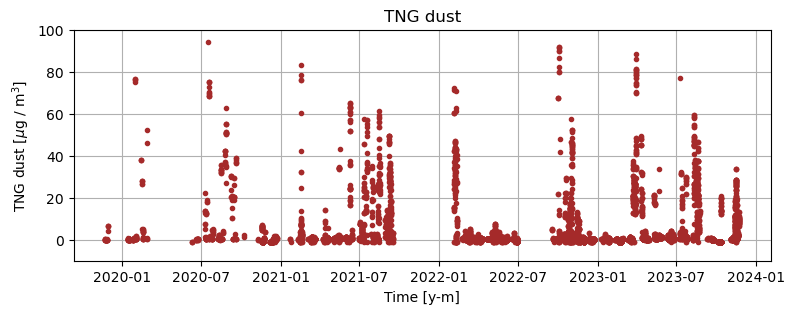

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, tng_dust, marker=".", ls="", color="brown")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("TNG dust [$\\mu$g / m${}^3$]"); ax.set_title("TNG dust")
ax.grid(); ax.set_ylim(-10, 100)

plt.savefig(f"plots/evolution_ws_tng_dust.png", bbox_inches="tight", dpi=300)
plt.show()

##### TNG seeing

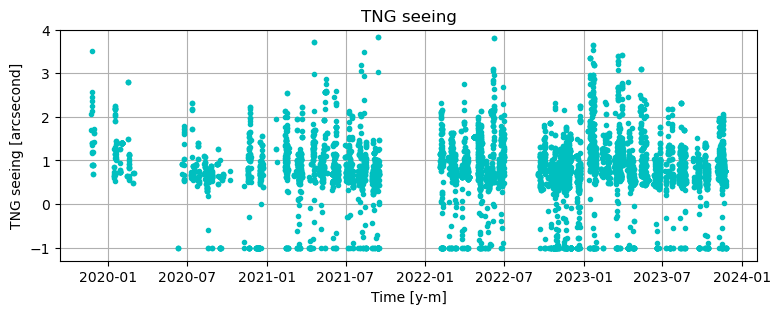

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, tng_seeing, marker=".", ls="", color="c")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("TNG seeing [arcsecond]"); ax.set_title("TNG seeing")
ax.grid(); ax.set_ylim(-1.3, 4)

plt.savefig(f"plots/evolution_ws_tng_seeing.png", bbox_inches="tight", dpi=300)
plt.show()

##### Other phenomena

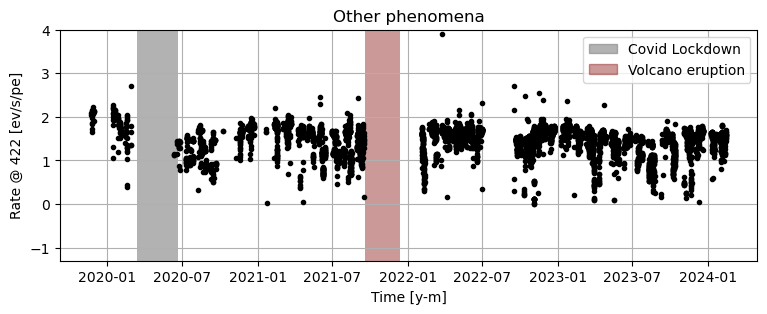

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

ax.plot(timestamp, pwl_norm, marker=".", ls="", color="k")

# Covid Lockdown
ax.axvspan(covid_lockdown[0], covid_lockdown[1], color="gray", alpha=0.6, ls="", label="Covid Lockdown")
# Volcano eruption
ax.axvspan(volcano_eruption[0], volcano_eruption[1], color="maroon", alpha=0.4, ls="", label="Volcano eruption")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Rate @ 422 [ev/s/pe]"); ax.set_title("Other phenomena")
ax.grid(); ax.set_ylim(-1.3, 4); ax.legend()


plt.savefig(f"plots/evolution_others.png", bbox_inches="tight", dpi=300)
plt.show()

##### TNG dust and rates

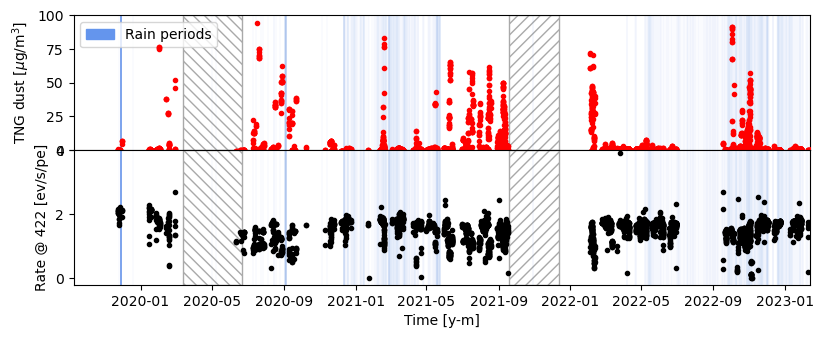

In [29]:
fig, (ax2, ax) = plt.subplots(2, 1, figsize=(9.5, 3.5), sharex=True)

ax.plot(timestamp, pwl_norm, marker=".", ls="", color="k", zorder=10)
ax2.plot(timestamp, tng_dust, marker=".", ls="", color="r", zorder=10)

for axe in [ax, ax2]:
    for i in range(len(rain_start)):
        axe.axvline((rain_start[i] + (rain_end[i] - rain_start[i])/2 ) , color="cornflowerblue", alpha=0.9, lw=0.05)
    
    # Covid Lockdown
    axe.axvspan(covid_lockdown[0], covid_lockdown[1], ls="-",
              facecolor="none", hatch="\\\\\\", edgecolor="darkgray")
    # Volcano eruption
    axe.axvspan(volcano_eruption[0], volcano_eruption[1], ls="-",
              facecolor="none", hatch="///", edgecolor="darkgray")

ax2.axvspan(None, None, color="cornflowerblue", label="Rain periods")

ax2.legend(ncols=1, frameon=True); ax2.set_ylabel("TNG dust [$\mu$g/m$^3$]")
ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Rate @ 422 [ev/s/pe]"); 
ax.set_ylim(-0.2, 4); ax2.set_ylim(0, 100)
ax.set_xlim(18148, 19400); plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig(f"plots/evolution_multiple.png", bbox_inches="tight", dpi=300)
plt.show()

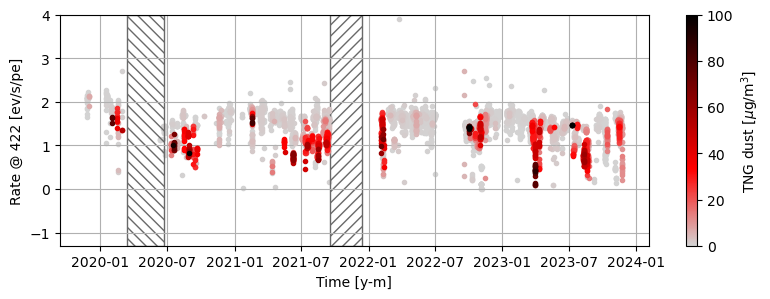

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(9.5, 3))

mask_weather = ~np.isnan(tng_dust)

pcols = ["lightgray", "r", "maroon", "k"]
ran   = [0, 100]
colors = plotting.get_colors_multiplot(tng_dust[mask_weather], input_colors=pcols, range=ran)

cmap   = plotting.create_cmap_from_colors(pcols)
for i in range(len(timestamp[mask_weather])):

    if tng_dust[mask_weather][i] != None:
        ax.plot(timestamp[mask_weather][i], pwl_norm[mask_weather][i],
                marker=".", ls="", color=colors[i], zorder=tng_dust[mask_weather][i])

plotting.plot_colorbar(fig, ax, ran, cmap, label="TNG dust [$\mu$g/m$^3$]")

# Covid Lockdown
ax.axvspan(covid_lockdown[0], covid_lockdown[1], ls="-", label="Covid Lockdown",
          facecolor="none", hatch="\\\\\\", edgecolor="dimgray")
# Volcano eruption
ax.axvspan(volcano_eruption[0], volcano_eruption[1], ls="-", label="Volcano eruption",
          facecolor="none", hatch="///", edgecolor="dimgray")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Rate @ 422 [ev/s/pe]")
ax.grid(); ax.set_ylim(-1.3, 4)

plt.savefig(f"plots/evolution_drdi_vs_dust.png", bbox_inches="tight", dpi=300)
plt.show()

##### TNG seeing and rates

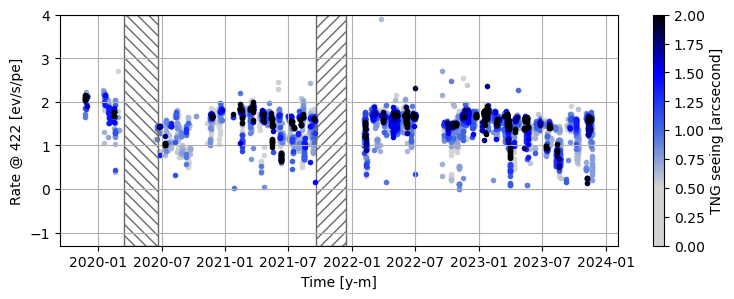

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(9, 3))

mask_weather = ~np.isnan(tng_dust)

pcols = ["lightgray", "lightgray", "royalblue", "b", "k"]
ran   = [0, 2]
colors = plotting.get_colors_multiplot(tng_seeing[mask_weather], input_colors=pcols, range=ran)
cmap   = plotting.create_cmap_from_colors(pcols)
for i in range(len(timestamp[mask_weather])):

    if tng_dust[mask_weather][i] != None:
        ax.plot(timestamp[mask_weather][i], pwl_norm[mask_weather][i],
                marker=".", ls="", color=colors[i], zorder=tng_seeing[mask_weather][i])

plotting.plot_colorbar(fig, ax, ran, cmap, label="TNG seeing [arcsecond]")

# Covid Lockdown
ax.axvspan(covid_lockdown[0], covid_lockdown[1], ls="-",
          facecolor="none", hatch="\\\\\\", edgecolor="dimgray")
# Volcano eruption
ax.axvspan(volcano_eruption[0], volcano_eruption[1], ls="-",
          facecolor="none", hatch="///", edgecolor="dimgray")

ax.set_xlabel("Time [y-m]"); ax.set_ylabel("Rate @ 422 [ev/s/pe]")
ax.grid(); ax.set_ylim(-1.3, 4)

plt.savefig(f"plots/evolution_drdi_vs_seeing.png", bbox_inches="tight", dpi=300)
plt.show()

##### TNG dust vs Rates

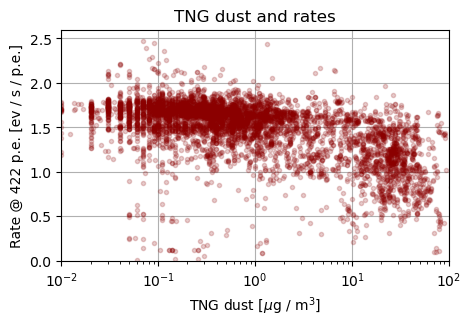

In [42]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(tng_dust, pwl_norm, marker=".", alpha=0.2, ls="", color="darkred")

ax.set_xlim(1e-2, 100); ax.set_ylim(0,2.6); ax.grid()
ax.set_xlabel("TNG dust [$\mu$g / m$^3$]"); ax.set_ylabel("Rate @ 422 p.e. [ev / s / p.e.]")
ax.set_title("TNG dust and rates"); ax.set_xscale("log")

plt.savefig(f"plots/plot_rates_vs_dust.png", bbox_inches="tight", dpi=300)
plt.show()

##### TNG seeing vs rates

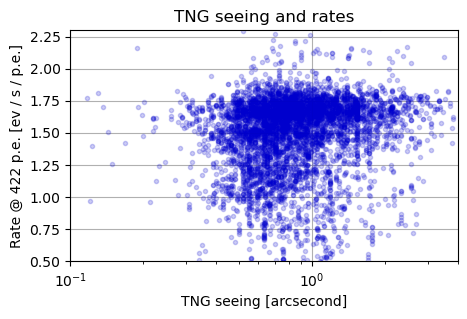

In [43]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(tng_seeing, pwl_norm, marker=".", alpha=0.2, ls="", color="mediumblue")

ax.set_xlim(1e-1, 4); ax.set_ylim(0.5,2.3); ax.grid()
ax.set_xlabel("TNG seeing [arcsecond]"); ax.set_ylabel("Rate @ 422 p.e. [ev / s / p.e.]")
ax.set_title("TNG seeing and rates"); ax.set_xscale("log")

plt.savefig(f"plots/plot_rates_vs_seeing.png", bbox_inches="tight", dpi=300)
plt.show()